# Proyecto 13: Pronósticos y predicciones

La cadena de gimnasios **Model Fitness** está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Tu tarea consiste en analizarlos y elaborar una estrategia de retención de clientes.

Tienes que:
- Aprender a predecir la probabilidad de pérdida (para el próximo mes) para cada cliente.
- Elaborar retratos de usuarios típicos: selecciona los grupos más destacados y describe sus características principales.
- Analizar los factores que más impactan la pérdida.
- Sacar conclusiones básicas y elaborar recomendaciones para mejorar la atención al cliente:
  - identificar a los grupos objetivo
  - sugerir medidas para reducir la rotación
  - describir cualquier otro patrón que observes con respecto a la interacción con los clientes

## 1. Inicialización y vista previa

In [5]:
# importar librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [6]:
# leer archivo y vista previa
#df = pd.read_csv('https://code.s3.yandex.net/datasets/gym_churn.csv')  # Ruta en linea
#df = pd.read_csv('/datasets/gym_churn_us.csv')  # Ruta de la plataforma

df = pd.read_csv('../gym_churn_us.csv')
df.info()
print()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


Model Fitness aportó archivos CSV que contienen los datos sobre la cancelación de un mes en concreto e información del mes que lo precedía. 

El dataset incluye los siguientes campos:
- 'Churn' — la cancelación para el mes en cuestión

Campos de dataset actuales:

Datos del usuario del mes anterior
- 'gender' - genero del usuario/a
- 'Near_Location' — si el/la usuario/a vive o trabaja en el vecindario donde se encuentra el gimnasio.
- 'Partner' — si el/la usuario/a trabaja en una compañía asociada (el gimnasio tiene empresas asociadas cuyos empleados obtienen descuentos; en esos casos el gimnasio almacena información sobre los empleadores de los clientes).
- Promo_friends — si el/la usuario/a originalmente se inscribió mediante una oferta “trae a un/a amigo/a” (se utilizó el código promocional de un/a amigo/a cuando pagaron el primer abono).
- 'Phone' — si el/la usuario/a aportó el número de teléfono.
- 'Age' - edad
- 'Lifetime' — el tiempo (en meses) desde que el/la usuario/a llegó por primera vez al gimnasio.

Datos del registro de visitas y compras y datos sobre el estado actual de la membresía:  
- 'Contract_period' — 1 mes, 3 meses, 6 meses o 1 año.
- 'Month_to_end_contract' — los meses que faltan hasta que expire el contrato.
- 'Group_visits' — si el/la usuario/a participa en sesiones grupales.
- 'Avg_class_frequency_total' — frecuencia media de visitas por semana a lo largo de la vida del cliente.
- 'Avg_class_frequency_current_month' — frecuencia media de visitas por semana durante el mes en curso.
- 'Avg_additional_charges_total' — cantidad total de dinero gastado en otros servicios del gimnasio: cafetería, productos deportivos, cosméticos, masajes, etc.

In [7]:
print("Valores duplicados: ", df.duplicated().sum())

Valores duplicados:  0


La información muestra que no hay valores ausentes ni duplicados.  
Las columnas son del tipo de dato correcto.

Se continua con el EDA.

## 2. Análisis exploratorio de datos (EDA)

In [8]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [9]:
df.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


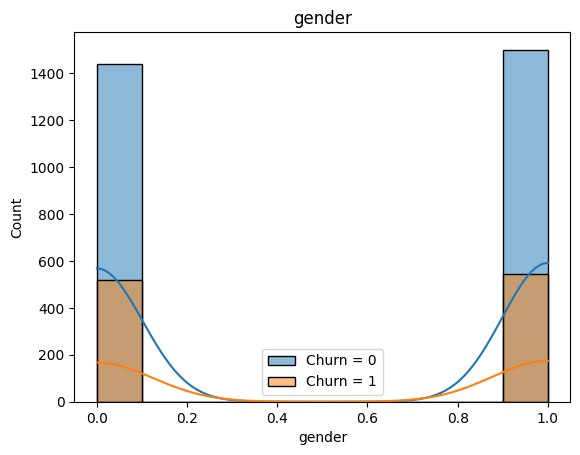

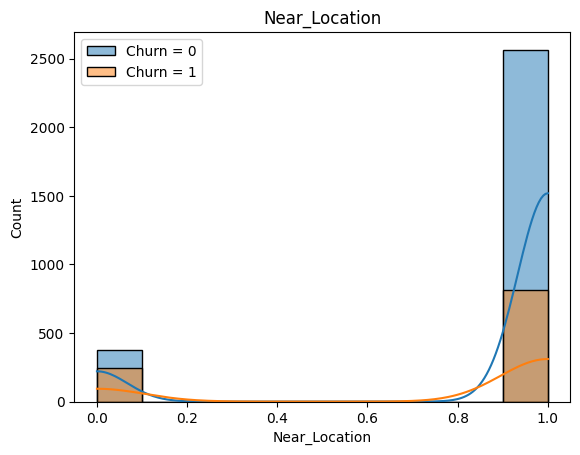

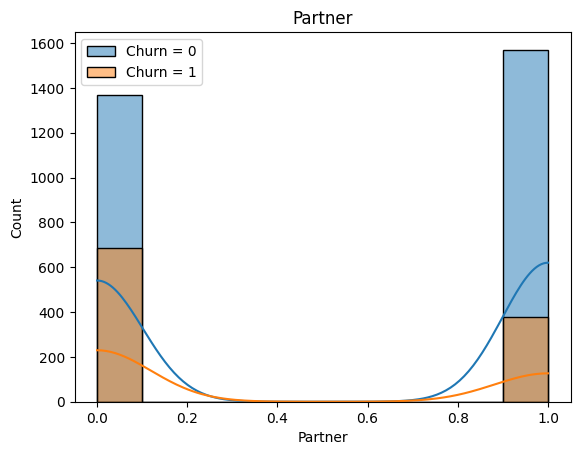

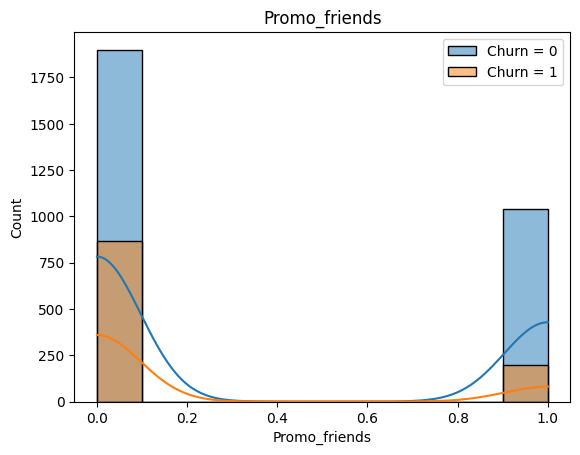

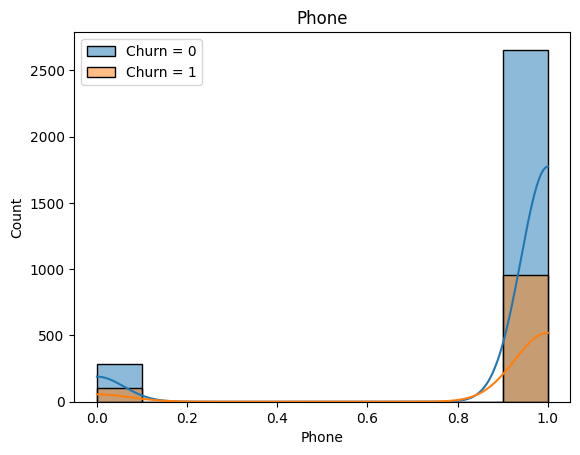

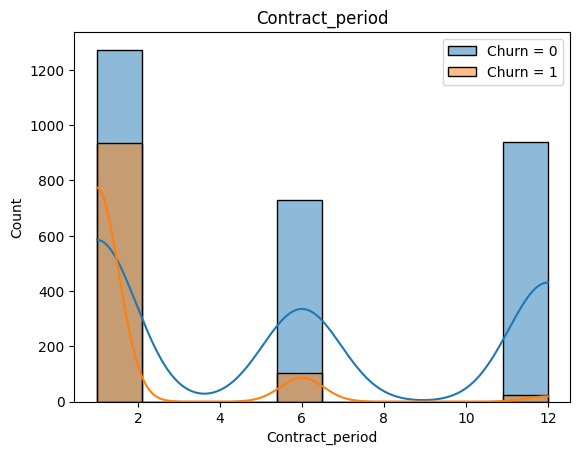

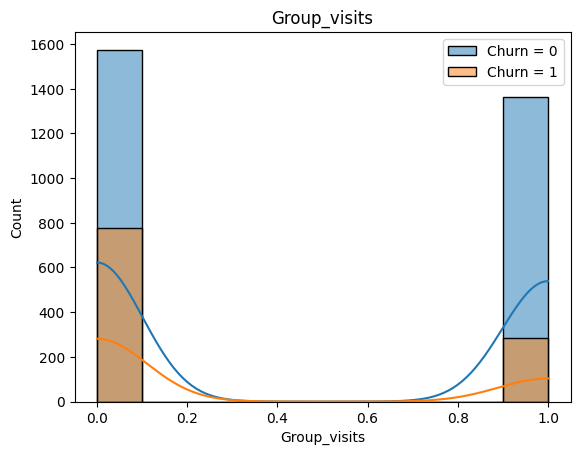

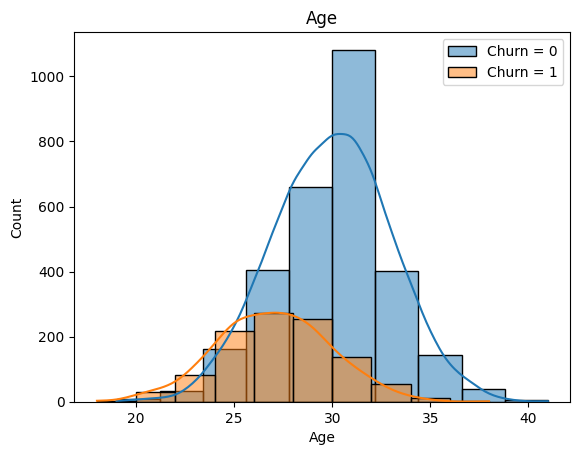

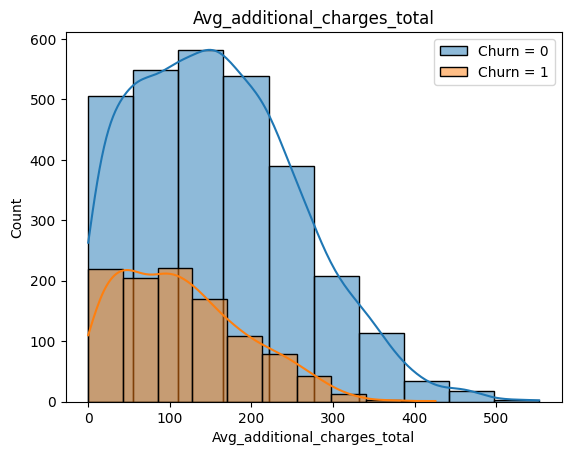

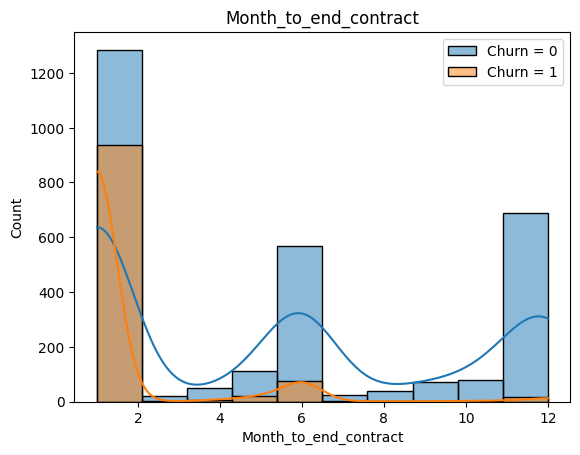

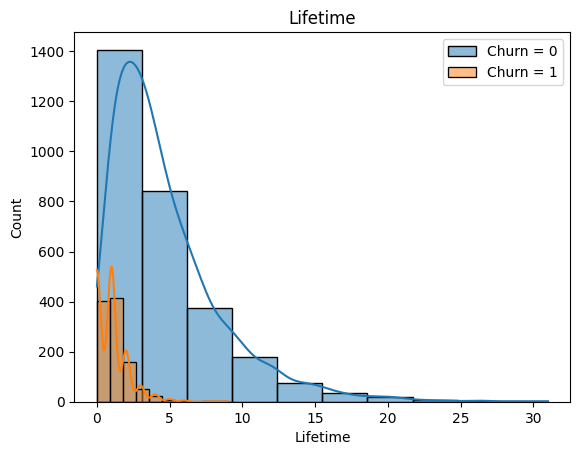

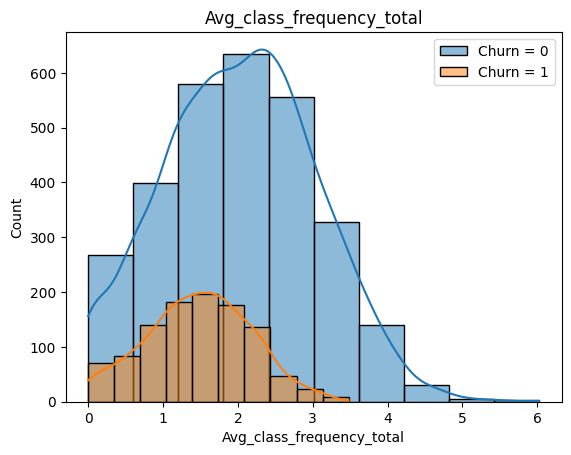

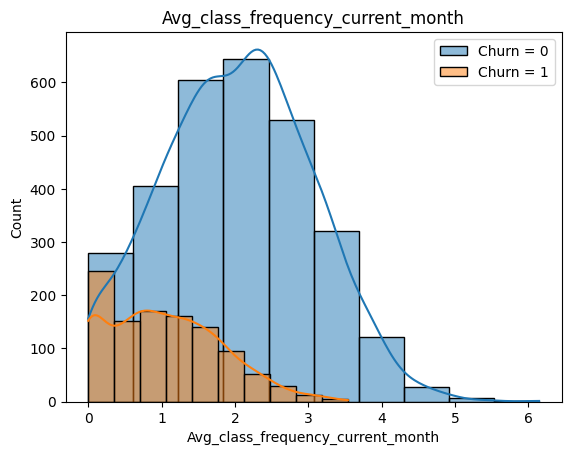

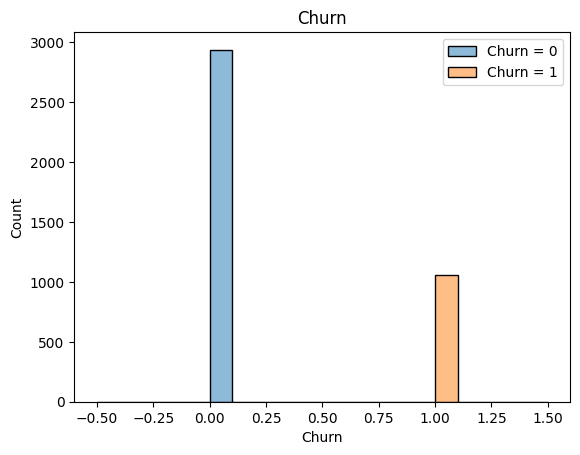

In [10]:
# Crear graficas con bucle
for col in df.columns:
    for value in df["Churn"].unique():
        sns.histplot(
            data=df[df["Churn"] == value],
            x=col,
            label=f'{"Churn"} = {value}',
            bins=10,
            kde=True
        )
    plt.title(col)
    plt.legend()
    plt.show()

In [11]:
df.corr()["Churn"].sort_values(ascending=False)

Churn                                1.000000
gender                               0.000708
Phone                               -0.001177
Near_Location                       -0.128098
Partner                             -0.157986
Promo_friends                       -0.162233
Group_visits                        -0.175325
Avg_additional_charges_total        -0.198697
Avg_class_frequency_total           -0.249715
Month_to_end_contract               -0.381393
Contract_period                     -0.389984
Age                                 -0.404735
Avg_class_frequency_current_month   -0.412348
Lifetime                            -0.438220
Name: Churn, dtype: float64

En base a la exploración anterior, se observa que
- Las columnas `gender` y `Phone` no estan relacionadas con la columna objetivo
- Las columnas `Age`, `Avg_class_frequency_current_month` y `Lifetime` muestran una alta relación

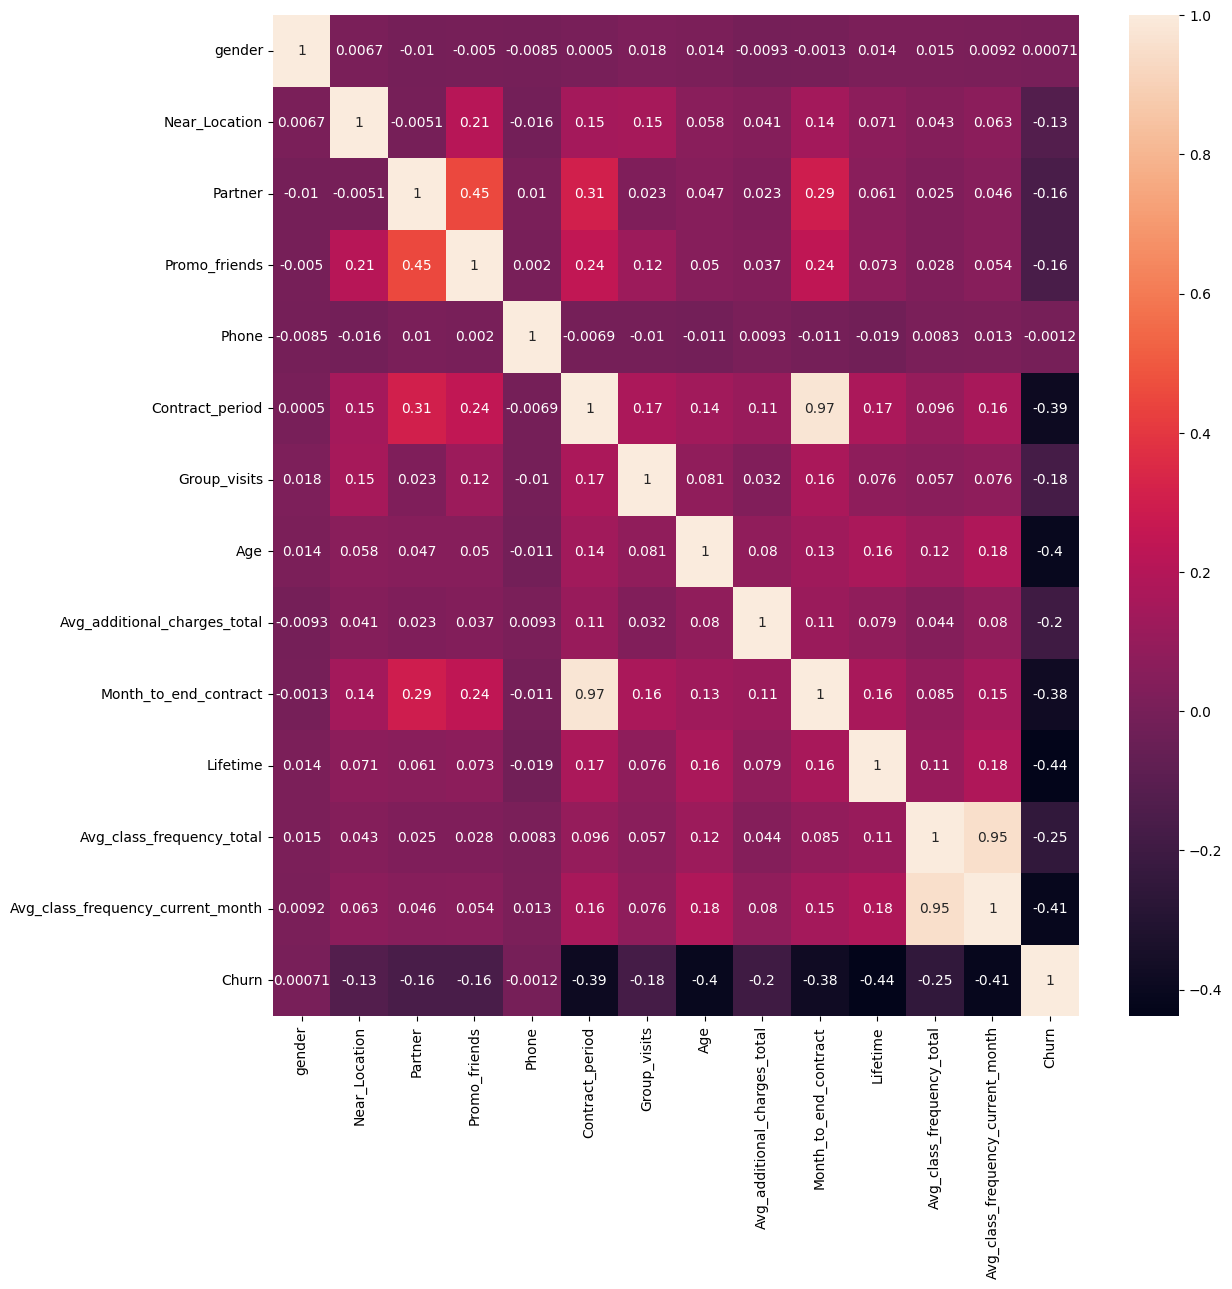

In [12]:
plt.figure(figsize = (13,13))
sns.heatmap(df.corr(), annot = True)
plt.show()

## 3. Modelo para predecir la cancelación de usuarios

In [13]:
# eliminar columnas que no estan relacionadas con la columna objetivo
df.drop(columns = ['gender', "Phone"], inplace=True)

#comprobar columnas
df.columns

Index(['Near_Location', 'Partner', 'Promo_friends', 'Contract_period',
       'Group_visits', 'Age', 'Avg_additional_charges_total',
       'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total',
       'Avg_class_frequency_current_month', 'Churn'],
      dtype='object')

In [14]:
# Separar los datos en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(df.drop(columns = ['Churn']), df['Churn'], test_size = 0.2)

In [15]:
# # Escalar los datos
# scaler = StandardScaler()
# X_train_s = scaler.fit_transform(X)
# y_train_s


### Modelo: Regresión logística

#### Datos sin escalar

In [16]:
#entrenar modelo
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
yt_proba_lr = lr_model.predict_proba(X_train)
yt_pred_lr  = lr_model.predict(X_train)

# Conjunto entrenamiento: evaluar exactitud, precisión y recall
print('Accuracy score for logistic regression is: {:.2f}'.format(accuracy_score(y_train, yt_pred_lr)))
print('Precision score for logistic regression is: {:.2f}'.format(precision_score(y_train, yt_pred_lr)))
print('Recall score for logistic regression is: {:.2f}'.format(recall_score(y_train, yt_pred_lr)))

Accuracy score for logistic regression is: 0.92
Precision score for logistic regression is: 0.89
Recall score for logistic regression is: 0.81


In [ ]:
y_proba_lr = lr_model.predict_proba(X_val)
y_pred_lr  = lr_model.predict(X_val)

# Conjunto validación: evaluar exactitud, precisión y recall
print('Accuracy score for logistic regression is: {:.2f}'.format(accuracy_score(y_val, y_pred_lr)))
print('Precision score for logistic regression is: {:.2f}'.format(precision_score(y_val, y_pred_lr)))
print('Recall score for logistic regression is: {:.2f}'.format(recall_score(y_val, y_pred_lr)))

Accuracy score for logistic regression is: 0.92
Precision score for logistic regression is: 0.88
Recall score for logistic regression is: 0.82


#### Datos escalados

### Modelo: Bosque aleatorio

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

In [ ]:
y_proba_rf = rf_model.predict_proba(X_val)
y_pred_rf = rf_model.predict(X_val)

# Conjunto validación: evaluar exactitud, precisión y recall
print('Accuracy score for random forest is: {:.2f}'.format(accuracy_score(y_val, y_pred_rf)))
print('Precision score for random forest is: {:.2f}'.format(precision_score(y_val, y_pred_rf)))
print('Recall score for random forest is: {:.2f}'.format(recall_score(y_val, y_pred_rf)))

## 4. Crear clústeres de usuarios/as

## 5. Conclusiones y recomendaciones